In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, silhouette_score

# Are there distinct groups of patients based on symptoms, and do these groups differ in diabetes outcomes?

In [3]:
# Are there distinct groups of patients based on symptoms, and do these groups differ in diabetes outcomes?
df = pd.read_csv("../files/early_diabetes_data_cleaned.csv")

target = df['class']
features = df.drop('class', axis=1).copy()

clusters = [i for i in range(2, 15)]
silhouettes = []

for cluster in clusters:
    kmeans = KMeans(n_clusters=cluster, random_state=0)
    label = kmeans.fit_predict(df)
    silhouettes.append(silhouette_score(df, label))

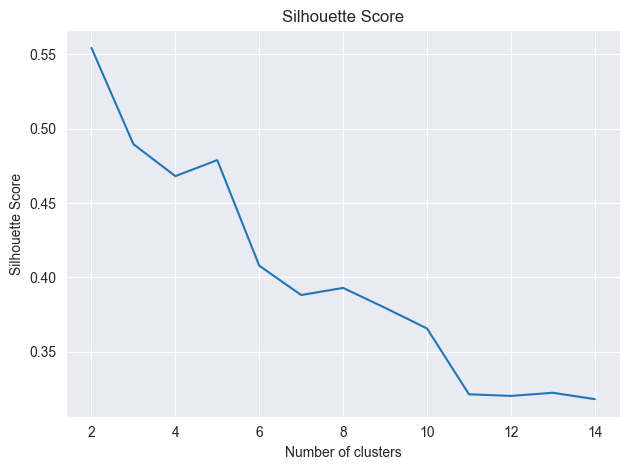

In [4]:
plt.title("Silhouette Score")
plt.plot(clusters, silhouettes)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.tight_layout()

In [5]:
kmeans = KMeans(n_clusters=2, random_state=0)
label = kmeans.fit_predict(df)
df_clustered = df.copy()
df_clustered['cluster'] = label
clustered_mean = df_clustered.groupby('cluster').mean().copy()
clustered_mean = np.transpose(clustered_mean).copy()
clustered_mean['factors'] = clustered_mean.index
clustered_mean = clustered_mean.reset_index(drop=True)
clustered_mean.columns = ['Cluster 1', 'Cluster 2', 'factors']

combined = clustered_mean.melt(
    id_vars="factors",
    value_vars=["Cluster 1", "Cluster 2"],
    var_name="Class",
    value_name="Value"
)

combined.head()
categorical_factors = combined.loc[combined['factors'] != 'Age', :].loc[combined['factors'] != 'Gender', :]
age = combined.loc[combined['factors'] == 'Age', :]
gender = combined.loc[combined['factors'] == 'Gender', :]

categorical_factors['Value'] = categorical_factors['Value']*100

In [6]:
clustered_mean

,Cluster 1,Cluster 2,factors
0,39.294915,59.480000,Age
1,0.383051,0.351111,Gender
2,0.433898,0.577778,Polyuria
3,0.406780,0.502222,Polydipsia
4,0.400000,0.440000,sudden weight loss
5,0.505085,0.693333,weakness
6,0.332203,0.617778,Polyphagia
7,0.220339,0.226667,Genital thrush
8,0.274576,0.675556,visual blurring
9,0.403390,0.595556,Itching


In [126]:
categorical_factors

,factors,Class,Value
2,Polyuria,Cluster 1,0.433898
3,Polydipsia,Cluster 1,0.406780
4,sudden weight loss,Cluster 1,0.400000
5,weakness,Cluster 1,0.505085
6,Polyphagia,Cluster 1,0.332203
7,Genital thrush,Cluster 1,0.220339
8,visual blurring,Cluster 1,0.274576
9,Itching,Cluster 1,0.403390
10,Irritability,Cluster 1,0.186441
11,delayed healing,Cluster 1,0.342373


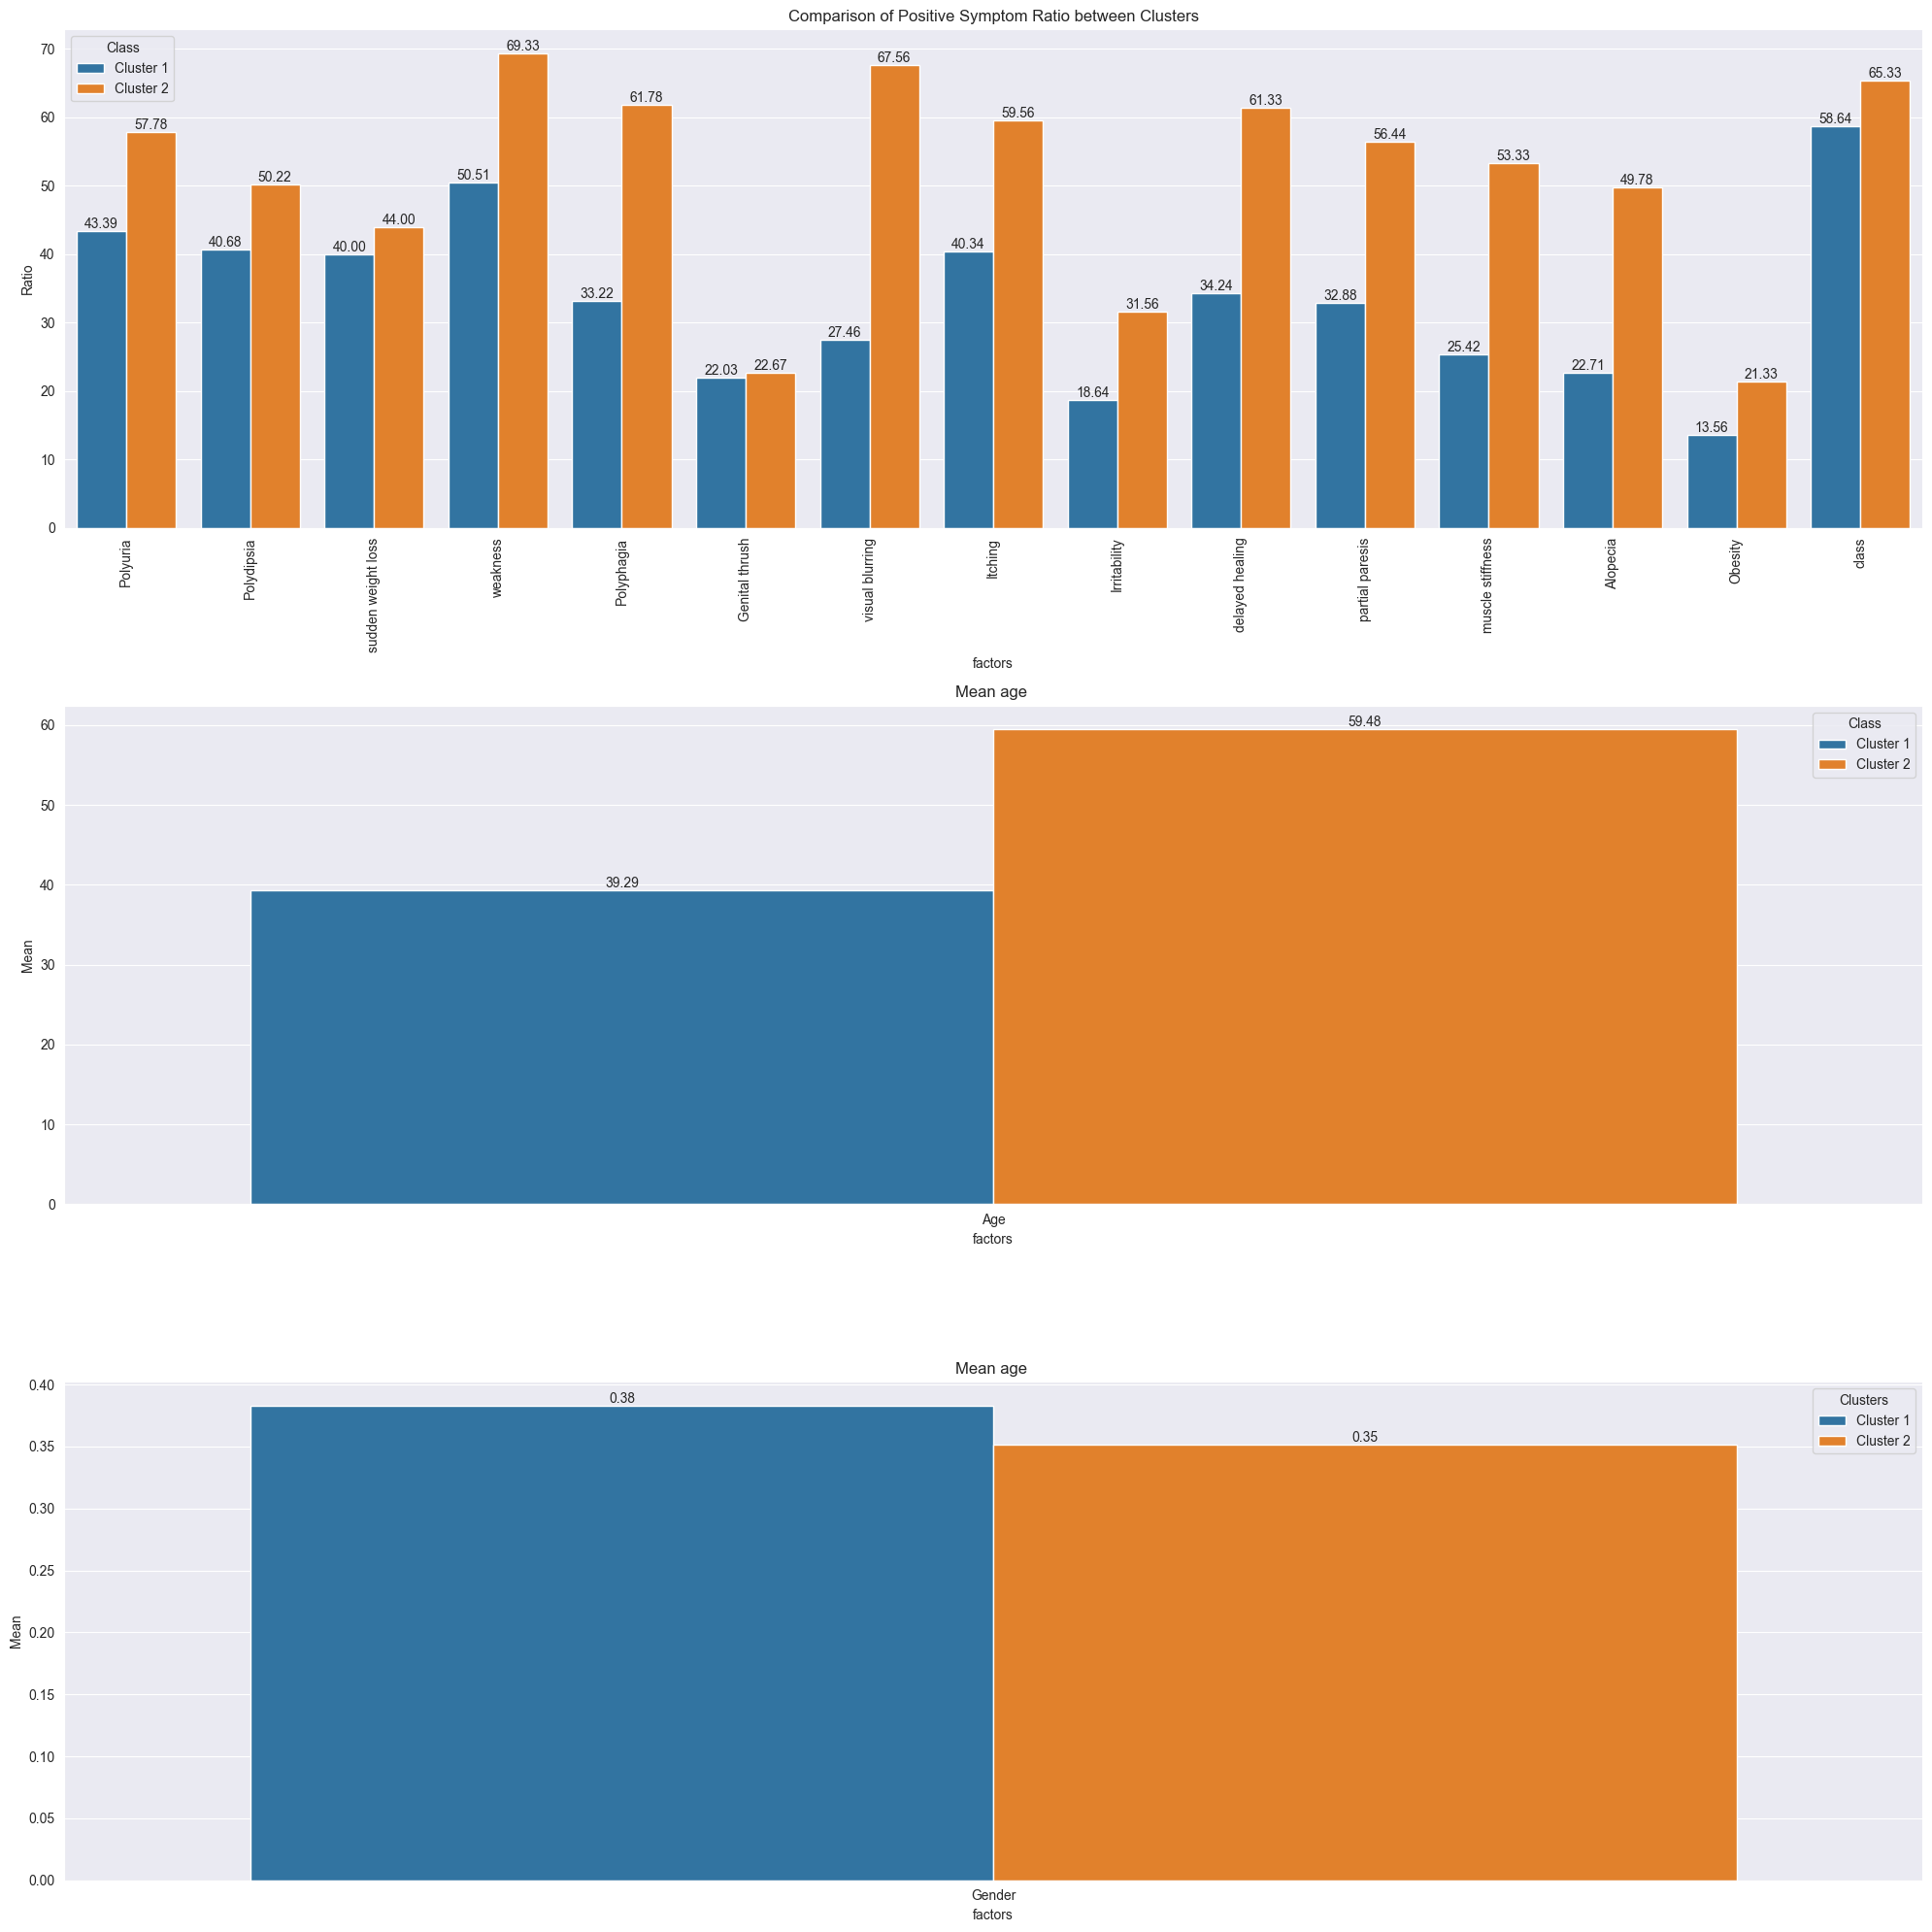

In [132]:
fig, axs = plt.subplots(3, 1, figsize=(20, 20))

sns.barplot(data=categorical_factors, x='factors', y='Value', hue='Class', ax=axs[0])
axs[0].tick_params(axis='x', rotation=90)
axs[0].set_ylabel('Ratio')
axs[0].set_title('Comparison of Positive Symptom Ratio between Clusters')

sns.barplot(data=age, x='factors', y='Value', hue='Class', ax=axs[1])
axs[1].set_title('Mean age ')
axs[1].set_ylabel('Mean')

sns.barplot(data=gender, x='factors', y='Value', hue='Class', ax=axs[2])
axs[2].set_title('Mean age ')
axs[2].set_ylabel('Mean')

for ax in axs:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

plt.legend(title='Clusters')
plt.tight_layout()
plt.show()